# 🏥 Notebook 06 – Tiền xử lý & Huấn luyện: BỆNH GAN (LIVER DISEASE)
**Dataset:** `indian_liver_patient.csv` (583 bệnh nhân)  
**Sinh viên:** Lê Trung Hiếu – 102220187

---
### ⚠️ Đặc thù dataset
| Đặc điểm | Chi tiết |
|---------|----------|
| Kích thước | 583 mẫu (nhỏ hơn Stroke 5.1K, lớn hơn Kidney 400) |
| Chất lượng | Rất sạch: chỉ 4 NaN (0.7%) trong 1 cột |
| Features | 10 clinical markers (liver enzymes, protein levels) |
| Target | Dataset: 1=Gan bệnh (416), 2=Bình thường (167) |
| Cân bằng | Lệch 71%:29% → SMOTE giúp |

---

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 📦 PHẦN 0: IMPORT

In [2]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns, matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve, precision_recall_curve)
import xgboost as xgb
from imblearn.over_sampling import SMOTE
import shap, joblib, os

# ==============================================================
# ✅ KHAI BÁO ĐƯỜNG DẪN ROOT ĐẾN GOOGLE DRIVE
# ==============================================================
DRIVE_PATH = '/content/drive/MyDrive/DATN_HealthRisk'
DIR_DATA = f'{DRIVE_PATH}/data'
DIR_MODELS = f'{DRIVE_PATH}/models'
DIR_RESULTS = f'{DRIVE_PATH}/results'

for d in [DIR_DATA, DIR_MODELS, DIR_RESULTS]:
    os.makedirs(d, exist_ok=True)

plt.style.use('seaborn-v0_8-darkgrid'); sns.set_palette("husl")
print("✅ Import thành công và đã trỏ đường dẫn gốc vào Google Drive!")


✅ Import thành công và đã trỏ đường dẫn gốc vào Google Drive!


---
## 📋 PHẦN 1: KHÁM PHÁ DỮ LIỆU

### 1.1 Load & kiểm tra chất lượng

In [3]:
df_raw = pd.read_csv(f'{DIR_DATA}/indian_liver_patient.csv')

print("=" * 70)
print("📊 LIVER DISEASE DATASET – 583 bệnh nhân")
print("=" * 70)
print(f"  Shape   : {df_raw.shape}")
print(f"  Columns : {df_raw.columns.tolist()}")
display(df_raw.head(3))

print("\n🔍 Giải nghĩa các cột (chỉ số gan lâm sàn):")
col_desc = {
    'Age'                        : 'Tuổi (năm)',
    'Gender'                     : 'Giới tính: Male/Female',
    'Total_Bilirubin'            : 'Bilirubin tổng (mg/dL) - chỉ số gan',
    'Direct_Bilirubin'           : 'Bilirubin trực tiếp (mg/dL)',
    'Alkaline_Phosphotase'       : 'Phosphatase kiềm - enzyme gan (U/L)',
    'Alamine_Aminotransferase'   : 'ALT - enzyme gan (U/L)',
    'Aspartate_Aminotransferase' : 'AST - enzyme gan (U/L)',
    'Total_Protiens'             : 'Protein tổng (g/dL)',
    'Albumin'                    : 'Albumin (g/dL)',
    'Albumin_and_Globulin_Ratio' : 'Tỷ lệ Albumin/Globulin',
    'Dataset'                    : 'TARGET: 1=Gan bệnh, 2=Bình thường',
}
for col, desc in col_desc.items():
    print(f"  {col:30s}: {desc}")

print("\n🔍 PHÂN TÍCH CHẤT LƯỢNG DỮ LIỆU")
print("=" * 70)

print("1️⃣  Null values:")
null_counts = df_raw.isnull().sum()
print(f"   Total: {null_counts.sum()} missing values ({null_counts.sum()/(df_raw.shape[0]*df_raw.shape[1])*100:.2f}%)")
if null_counts.sum() > 0:
    print("   Per column:")
    print(null_counts[null_counts > 0])

print("\n2️⃣  Nhãn target (Dataset):")
vc = df_raw['Dataset'].value_counts().sort_index()
print(f"   Class 1 (Gan bệnh)     : {vc[1]:,} ({vc[1]/len(df_raw)*100:.1f}%)")
print(f"   Class 2 (Bình thường)  : {vc[2]:,} ({vc[2]/len(df_raw)*100:.1f}%)")
imb_ratio = max(vc.values) / min(vc.values)
print(f"   Imbalance ratio: {imb_ratio:.2f}:1 {'⚠️  Lệch' if imb_ratio > 2 else '✓ Tương đối cân bằng'}")

print("\n3️⃣  Dạng dữ liệu:")
print(f"   Numeric: {df_raw.select_dtypes('number').shape[1]} cột")
print(f"   Object (text/category): {df_raw.select_dtypes('object').shape[1]} cột")
print(f"   {df_raw.select_dtypes('object').columns.tolist()}")

print("\n4️⃣  Phạm vi giá trị lâm sàn (Clinical markers):")
for col in ['Age', 'Total_Bilirubin', 'Alkaline_Phosphotase', 'Alamine_Aminotransferase']:
    print(f"   {col:30s}: {df_raw[col].min():.1f} → {df_raw[col].max():.1f}  (mean={df_raw[col].mean():.1f})")

📊 LIVER DISEASE DATASET – 583 bệnh nhân
  Shape   : (583, 11)
  Columns : ['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin', 'Albumin_and_Globulin_Ratio', 'Dataset']


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1



🔍 Giải nghĩa các cột (chỉ số gan lâm sàn):
  Age                           : Tuổi (năm)
  Gender                        : Giới tính: Male/Female
  Total_Bilirubin               : Bilirubin tổng (mg/dL) - chỉ số gan
  Direct_Bilirubin              : Bilirubin trực tiếp (mg/dL)
  Alkaline_Phosphotase          : Phosphatase kiềm - enzyme gan (U/L)
  Alamine_Aminotransferase      : ALT - enzyme gan (U/L)
  Aspartate_Aminotransferase    : AST - enzyme gan (U/L)
  Total_Protiens                : Protein tổng (g/dL)
  Albumin                       : Albumin (g/dL)
  Albumin_and_Globulin_Ratio    : Tỷ lệ Albumin/Globulin
  Dataset                       : TARGET: 1=Gan bệnh, 2=Bình thường

🔍 PHÂN TÍCH CHẤT LƯỢNG DỮ LIỆU
1️⃣  Null values:
   Total: 4 missing values (0.06%)
   Per column:
Albumin_and_Globulin_Ratio    4
dtype: int64

2️⃣  Nhãn target (Dataset):
   Class 1 (Gan bệnh)     : 416 (71.4%)
   Class 2 (Bình thường)  : 167 (28.6%)
   Imbalance ratio: 2.49:1 ⚠️  Lệch

3️⃣  Dạng dữ liệu:


---
## ⚙️ PHẦN 2: TIỀN XỬ LÝ

### 2.1 Làm sạch & Encoding

🔍 TIỀN XỬ LÝ & KHÁM PHÁ DỮ LIỆU – LIVER DISEASE
1️⃣  Imputation: 4 missing values → median
🔁 Log-transform enzymes: ['Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Aspartate_Aminotransferase']
2️⃣  Target: Dataset 2→0 (Bình thường), Dataset 1→1 (Có bệnh gan)
   Distribution: {1: 416, 0: 167}



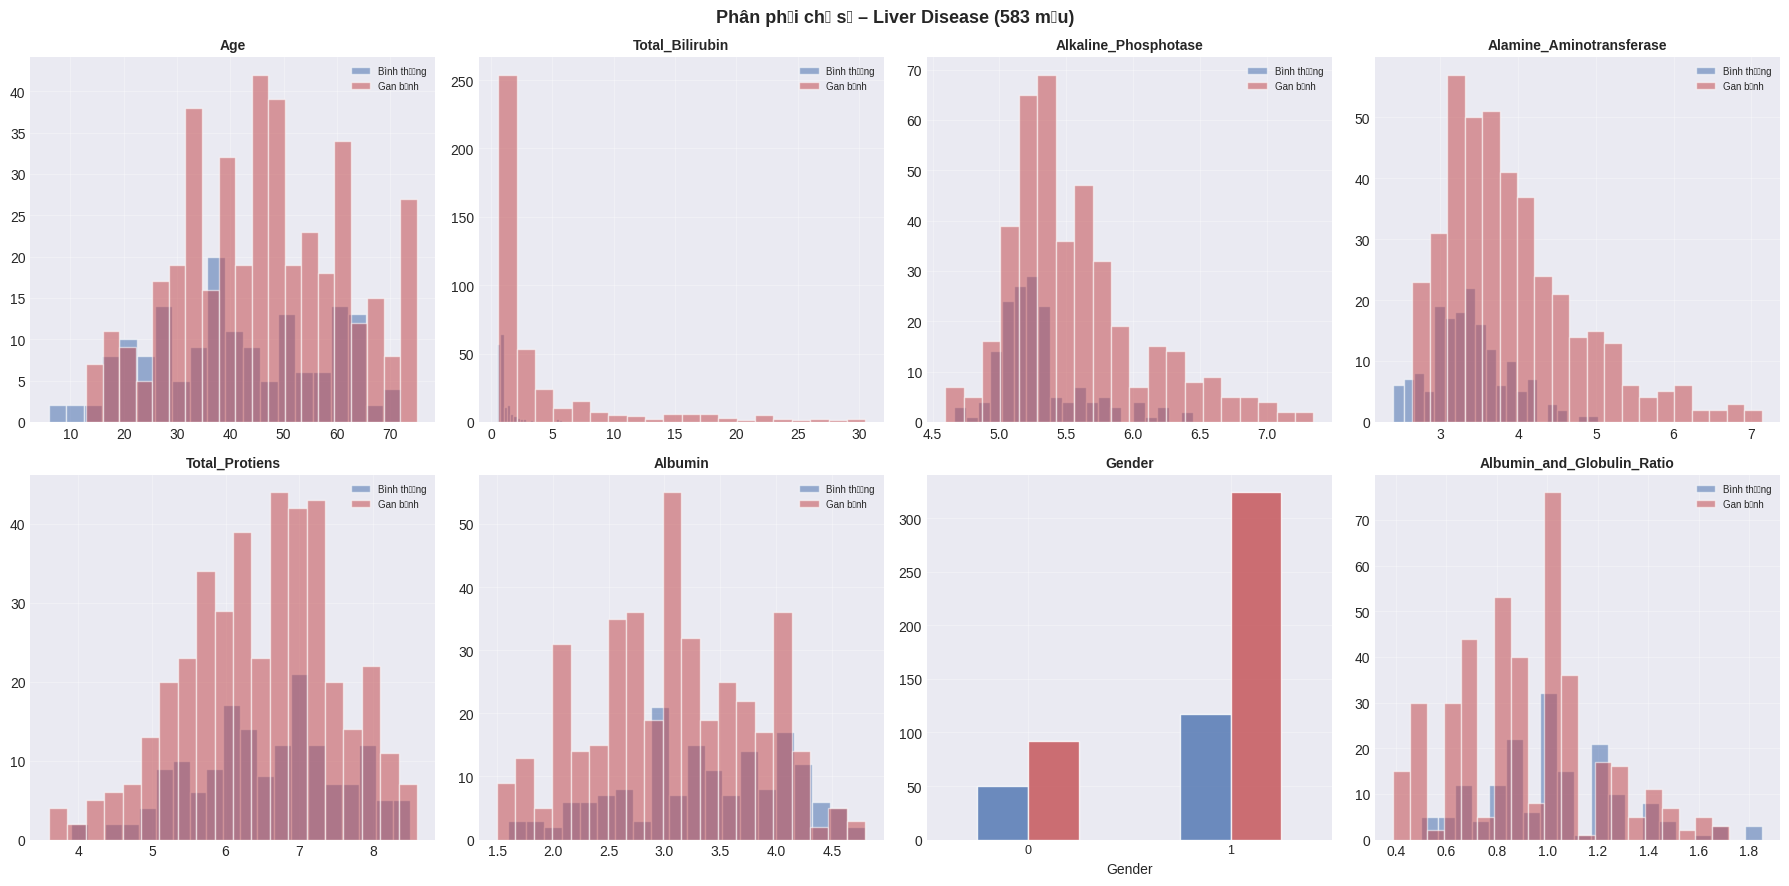

In [4]:
from sklearn.impute import SimpleImputer

print("🔍 TIỀN XỬ LÝ & KHÁM PHÁ DỮ LIỆU – LIVER DISEASE")
print("=" * 70)

df = df_raw.copy()

# ── BƯỚC 1: Impute missing values
imputer = SimpleImputer(strategy='median')
numeric_cols = df.select_dtypes('number').columns
# apply imputer to numeric columns only
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])
print(f"1️⃣  Imputation: {df_raw.isnull().sum().sum()} missing values → median")

# Log-transform skewed liver enzyme columns to stabilize variance
enzyme_cols = [c for c in ['Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Aspartate_Aminotransferase'] if c in df.columns]
if enzyme_cols:
    print(f"🔁 Log-transform enzymes: {enzyme_cols}")
    df[enzyme_cols] = np.log1p(df[enzyme_cols])

# ── BƯỚC 2 & 3: Encode & Remap Target
if 'Gender' in df.columns:
    df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})

if 'Dataset' in df.columns:
    df['liver_disease'] = (df['Dataset'] == 1).astype(int)
    df = df.drop(columns=['Dataset'])
    print(f"2️⃣  Target: Dataset 2→0 (Bình thường), Dataset 1→1 (Có bệnh gan)")
    print(f"   Distribution: {df['liver_disease'].value_counts().to_dict()}\n")

# ==========================================
# 📊 VẼ BIỂU ĐỒ PHÂN PHỐI EDA
# ==========================================
df_plot = df.copy()
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Phân phối chỉ số – Liver Disease (583 mẫu)', fontsize=13, weight='bold')

plot_cols = ['Age', 'Total_Bilirubin', 'Alkaline_Phosphotase', 'Alamine_Aminotransferase',
             'Total_Protiens', 'Albumin', 'Gender', 'Albumin_and_Globulin_Ratio']

for idx, col in enumerate(plot_cols):
    ax = axes[idx//4, idx%4]
    if df_plot[col].dtype == 'object' or df_plot[col].nunique() <= 4:
        ct = df_plot.groupby([col, 'liver_disease']).size().unstack(fill_value=0)
        ct.plot(kind='bar', ax=ax, color=['#4C72B0', '#C44E52'], alpha=0.8, edgecolor='white', legend=False)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center', fontsize=9)
    else:
        for label, color, name in [(0, '#4C72B0', 'Bình thường'), (1, '#C44E52', 'Gan bệnh')]:
            valid = df_plot[df_plot['liver_disease'] == label][col].dropna()
            try:
                valid = valid[(valid >= valid.quantile(0.01)) & (valid <= valid.quantile(0.99))]
            except: pass
            ax.hist(valid, bins=20, alpha=0.55, color=color, label=name, edgecolor='white')
        ax.legend(fontsize=7)
    ax.set_title(col, fontsize=10, weight='bold'); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DIR_RESULTS}/L01_eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# ── CHỐT FEATURES ĐỂ TRAIN
FEATURE_NAMES = [c for c in df.columns if c != 'liver_disease']
X = df.drop(columns=['liver_disease'])
y = df['liver_disease']

### 2.2 Correlation analysis

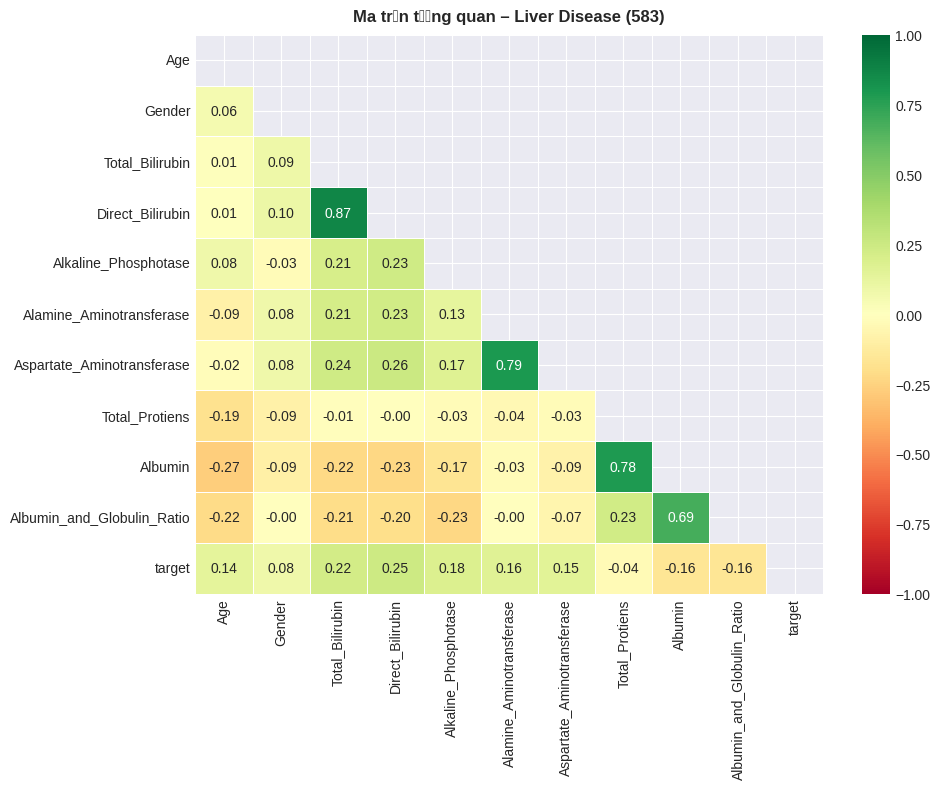

🔑 Top tương quan với nhãn target:
  Direct_Bilirubin               |███████                       | 0.246
  Total_Bilirubin                |██████                        | 0.220
  Alkaline_Phosphotase           |█████                         | 0.185
  Alamine_Aminotransferase       |████                          | 0.163
  Albumin_and_Globulin_Ratio     |████                          | 0.162
  Albumin                        |████                          | 0.161
  Aspartate_Aminotransferase     |████                          | 0.152
  Age                            |████                          | 0.137
  Gender                         |██                            | 0.082
  Total_Protiens                 |█                             | 0.035


In [5]:
# Prepare data for correlation: encode categorical
df_corr = df_raw.copy()
df_corr['Gender'] = df_corr['Gender'].map({'Female': 0, 'Male': 1})
df_corr['target'] = (df_corr['Dataset'] == 1).astype(int)  # 1=disease, 0=normal
df_corr = df_corr.drop(columns=['Dataset'])
df_corr = df_corr.fillna(df_corr.median())

plt.figure(figsize=(10, 8))
corr = df_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Ma trận tương quan – Liver Disease (583)', fontsize=12, weight='bold', pad=10)
plt.tight_layout()
plt.savefig(f'{DIR_RESULTS}/L02_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("🔑 Top tương quan với nhãn target:")
corr_target = corr['target'].drop('target').abs().sort_values(ascending=False)
for feat, val in corr_target.head(10).items():
    bar = '█' * int(val*30)
    print(f"  {feat:30s} |{bar:<30}| {val:.3f}")

### 2.3 Split → SMOTE → Scale

🔀 SPLIT/SMOTE/SCALE:
  Train: 466  |  Test: 117
  Train class: {0: np.int64(133), 1: np.int64(333)}
  Sau SMOTE: 666 | class: {0: np.int64(333), 1: np.int64(333)}
  💾 Lưu: liver_scaler.pkl | features.pkl | test_raw.pkl


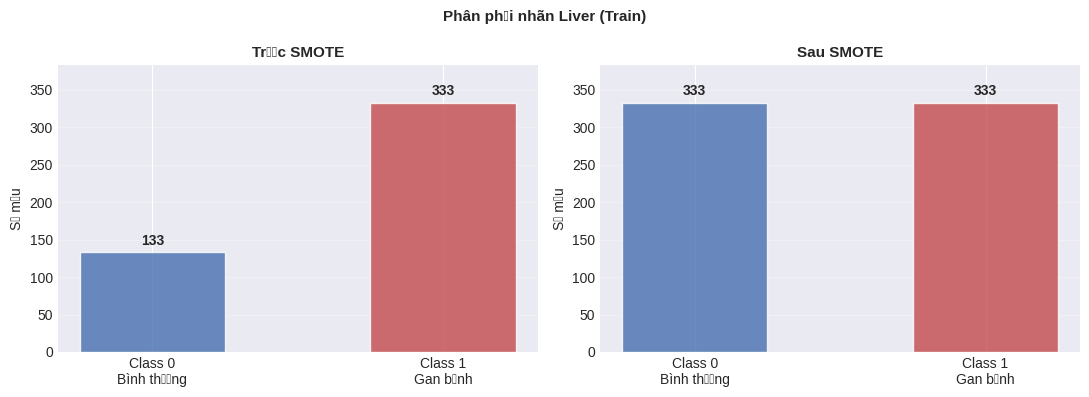

In [6]:
# ── BƯỚC 1: Split ─────────────────────────────────────────────────────────────
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print("🔀 SPLIT/SMOTE/SCALE:")
print(f"  Train: {X_train_raw.shape[0]:,}  |  Test: {X_test_raw.shape[0]:,}")
print(f"  Train class: {dict(y_train_raw.value_counts().sort_index())}")

# ── BƯỚC 2: SMOTE ─────────────────────────────────────────────────────────────
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train_raw, y_train_raw)
print(f"  Sau SMOTE: {X_train_res.shape[0]:,} | class: {dict(pd.Series(y_train_res).value_counts().sort_index())}")

# ── BƯỚC 3: Scale ─────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_d = scaler.fit_transform(X_train_res)
X_test_d  = scaler.transform(X_test_raw)
y_train_d = y_train_res
y_test_d  = y_test_raw.values

joblib.dump(scaler,        f'{DIR_MODELS}/liver_scaler.pkl')
joblib.dump(FEATURE_NAMES, f'{DIR_MODELS}/liver_features.pkl')
joblib.dump((X_test_raw.values, y_test_raw.values), f'{DIR_MODELS}/liver_test_raw.pkl')
print("  💾 Lưu: liver_scaler.pkl | features.pkl | test_raw.pkl")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, data, title in [(axes[0], y_train_raw, "Trước SMOTE"),
                         (axes[1], pd.Series(y_train_res), "Sau SMOTE")]:
    vc = pd.Series(data).value_counts().sort_index()
    bars = ax.bar(['Class 0\nBình thường', 'Class 1\nGan bệnh'], vc.values,
                  color=['#4C72B0', '#C44E52'], alpha=0.82, edgecolor='white', width=0.5)
    for bar, val in zip(bars, vc.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
                f'{val:,}', ha='center', fontsize=10, weight='bold')
    ax.set_title(title, fontsize=11, weight='bold')
    ax.set_ylabel('Số mẫu'); ax.set_ylim(0, max(vc.values)*1.15)
    ax.grid(axis='y', alpha=0.3)
plt.suptitle('Phân phối nhãn Liver (Train)', fontsize=11, weight='bold')
plt.tight_layout()
plt.savefig(f'{DIR_RESULTS}/L03_smote_balancing.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🤖 PHẦN 3: HUẤN LUYỆN XGBoost

### 3.1 GridSearchCV

🚀 XGBOOST + GRIDSEARCHCV (scoring=roc_auc)

📊 ĐÁNH GIÁ XGBOOST – LIVER DISEASE
  Accuracy: 0.7521 | Precision: 0.8000 | Recall: 0.8675 | AUC: 0.7668


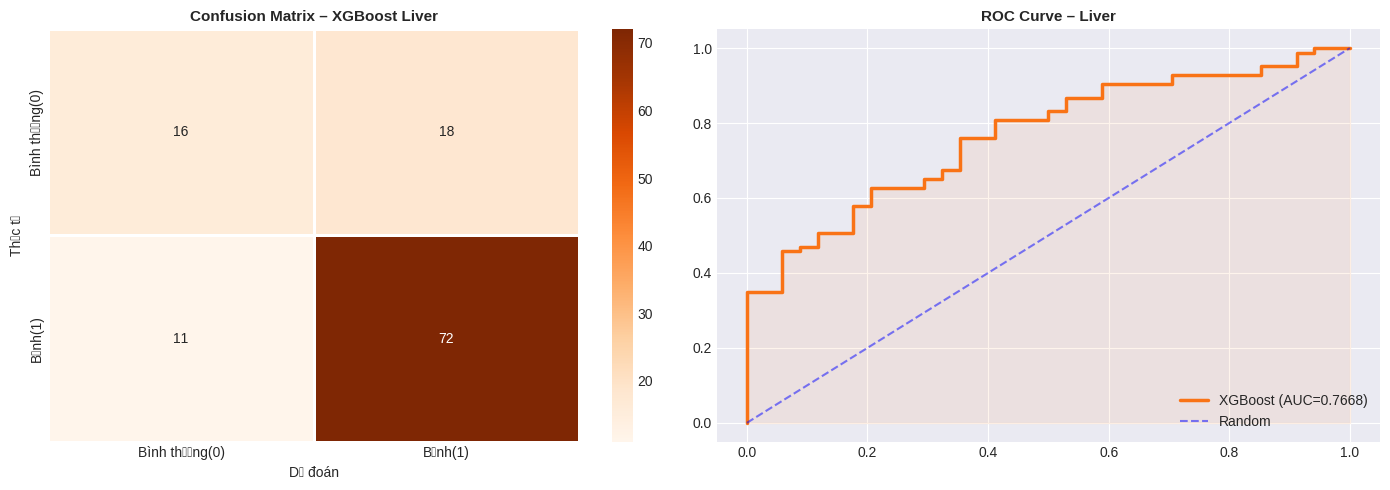

In [7]:
print("🚀 XGBOOST + GRIDSEARCHCV (scoring=roc_auc)")
param_grid = {'n_estimators': [100, 200], 'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.05, 0.1], 'subsample': [0.8], 'colsample_bytree': [0.8]}

xgb_base = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, verbosity=0, tree_method='hist', device='cuda', scale_pos_weight=(y_train_d==0).sum() / (y_train_d==1).sum())
cv_str = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gs = GridSearchCV(xgb_base, param_grid, cv=cv_str, scoring='roc_auc', n_jobs=1, verbose=0, refit=True)
gs.fit(X_train_d, y_train_d)
best_xgb = gs.best_estimator_

joblib.dump(best_xgb, f'{DIR_MODELS}/liver_xgboost.pkl')

# Đánh giá XGBoost
y_pred_xgb, y_prob_xgb = best_xgb.predict(X_test_d), best_xgb.predict_proba(X_test_d)[:, 1]
acc_xgb, prec_xgb, rec_xgb = accuracy_score(y_test_d, y_pred_xgb), precision_score(y_test_d, y_pred_xgb), recall_score(y_test_d, y_pred_xgb)
f1_xgb, auc_xgb = f1_score(y_test_d, y_pred_xgb), roc_auc_score(y_test_d, y_prob_xgb)

print("\n📊 ĐÁNH GIÁ XGBOOST – LIVER DISEASE")
print(f"  Accuracy: {acc_xgb:.4f} | Precision: {prec_xgb:.4f} | Recall: {rec_xgb:.4f} | AUC: {auc_xgb:.4f}")

# Vẽ CM và ROC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_test_d, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[0], xticklabels=['Bình thường(0)','Bệnh(1)'], yticklabels=['Bình thường(0)','Bệnh(1)'], linewidths=1, linecolor='white')
axes[0].set_title('Confusion Matrix – XGBoost Liver',fontsize=11,weight='bold')
axes[0].set_ylabel('Thực tế'); axes[0].set_xlabel('Dự đoán')

fpr,tpr,_ = roc_curve(y_test_d, y_prob_xgb)
axes[1].plot(fpr,tpr,color='#f97316',lw=2.5,label=f'XGBoost (AUC={auc_xgb:.4f})')
axes[1].plot([0,1],[0,1],'b--',lw=1.5,alpha=0.5,label='Random')
axes[1].fill_between(fpr,tpr,alpha=0.08,color='#f97316')
axes[1].legend(loc='lower right')
axes[1].set_title('ROC Curve – Liver',fontsize=11,weight='bold')

plt.tight_layout()
plt.savefig(f'{DIR_RESULTS}/L04_xgboost_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

🚀 TÌM NGƯỠNG TỐI ƯU (THRESHOLD F2)
🚀 HUẤN LUYỆN RANDOM FOREST (Baseline)

🏆 XGBoost vs RF – LIVER


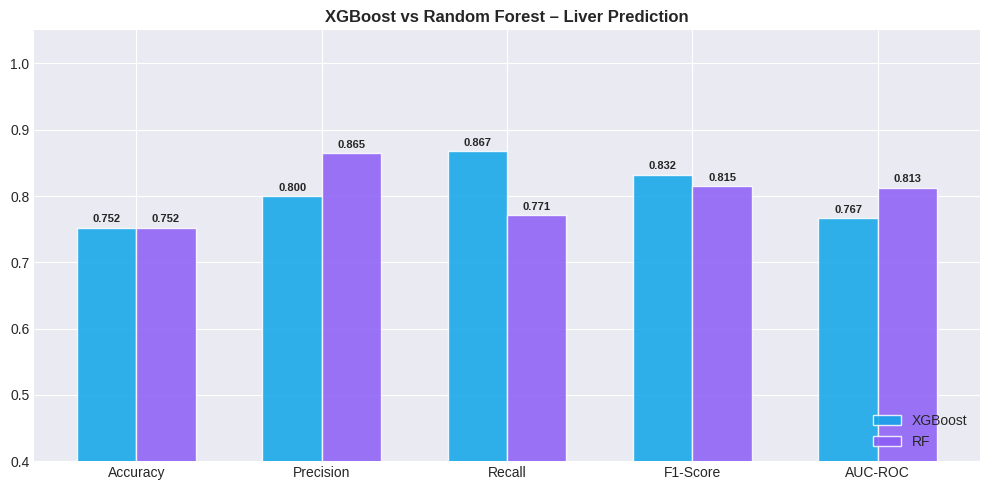

In [8]:
print("🚀 TÌM NGƯỠNG TỐI ƯU (THRESHOLD F2)")
precisions, recalls, thresholds = precision_recall_curve(y_test_d, y_prob_xgb)
f2_scores = (5*(precisions[:-1]*recalls[:-1]))/(4*precisions[:-1]+recalls[:-1]+1e-8)
best_t_f2 = thresholds[np.argmax(f2_scores)]
joblib.dump({'default':0.5, 'f2_medical':float(best_t_f2)}, f'{DIR_MODELS}/liver_thresholds.pkl')

print("🚀 HUẤN LUYỆN RANDOM FOREST (Baseline)")
rf_model = RandomForestClassifier(n_estimators=200, max_depth=7, random_state=42, n_jobs=-1, class_weight='balanced')
rf_model.fit(X_train_d, y_train_d)
joblib.dump(rf_model, f'{DIR_MODELS}/liver_randomforest.pkl')

y_pred_rf, y_prob_rf = rf_model.predict(X_test_d), rf_model.predict_proba(X_test_d)[:,1]
acc_rf, prec_rf, rec_rf = accuracy_score(y_test_d,y_pred_rf), precision_score(y_test_d,y_pred_rf), recall_score(y_test_d,y_pred_rf)
f1_rf, auc_rf = f1_score(y_test_d,y_pred_rf), roc_auc_score(y_test_d,y_prob_rf)

print("\n🏆 XGBoost vs RF – LIVER")
metrics_n = ['Accuracy','Precision','Recall','F1-Score','AUC-ROC']
xgb_s, rf_s = [acc_xgb, prec_xgb, rec_xgb, f1_xgb, auc_xgb], [acc_rf, prec_rf, rec_rf, f1_rf, auc_rf]

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(metrics_n)); w = 0.32
b1 = ax.bar(x - w/2, xgb_s, w, label='XGBoost', color='#0ea5e9', alpha=0.85, edgecolor='white')
b2 = ax.bar(x + w/2, rf_s,  w, label='RF',      color='#8b5cf6', alpha=0.85, edgecolor='white')
for bars in [b1, b2]:
    for bar in bars: ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, weight='bold')
ax.set_xticks(x); ax.set_xticklabels(metrics_n); ax.set_ylim([0.4, 1.05])
ax.set_title('XGBoost vs Random Forest – Liver Prediction', fontsize=12, weight='bold')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig(f'{DIR_RESULTS}/L05_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Đánh giá trên Test Set

📊 ĐÁNH GIÁ – LIVER DISEASE
  Metric     │ Score   │ Min   │ Trạng thái
  ──────────────────────────────────────────────────
  Accuracy   │  0.7521 │ ≥0.8 │ ❌ CHƯA ĐẠT
  Precision  │  0.8000 │ ≥0.75 │ ✅ ĐẠT
  Recall     │  0.8675 │ ≥0.75 │ ✅ ĐẠT
  F1         │  0.8324 │ ≥0.76 │ ✅ ĐẠT
  AUC        │  0.7668 │ ≥0.82 │ ❌ CHƯA ĐẠT

              precision    recall  f1-score   support

 Bình thường       0.59      0.47      0.52        34
    Gan bệnh       0.80      0.87      0.83        83

    accuracy                           0.75       117
   macro avg       0.70      0.67      0.68       117
weighted avg       0.74      0.75      0.74       117



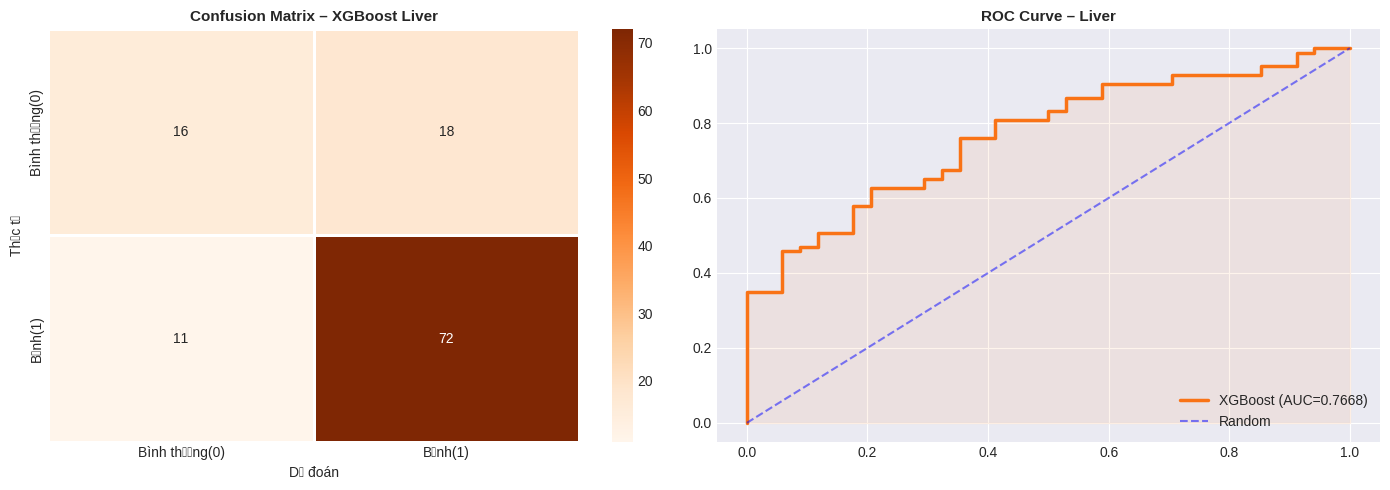

In [9]:
y_pred_xgb = best_xgb.predict(X_test_d)
y_prob_xgb = best_xgb.predict_proba(X_test_d)[:, 1]
acc_xgb  = accuracy_score(y_test_d, y_pred_xgb)
prec_xgb = precision_score(y_test_d, y_pred_xgb)
rec_xgb  = recall_score(y_test_d, y_pred_xgb)
f1_xgb   = f1_score(y_test_d, y_pred_xgb)
auc_xgb  = roc_auc_score(y_test_d, y_prob_xgb)

THRESH = {'Accuracy':0.80,'Precision':0.75,'Recall':0.75,'F1':0.76,'AUC':0.82}
SCORES = {'Accuracy':acc_xgb,'Precision':prec_xgb,'Recall':rec_xgb,'F1':f1_xgb,'AUC':auc_xgb}
print("📊 ĐÁNH GIÁ – LIVER DISEASE")
print("=" * 70)
print(f"  {'Metric':10s} │ {'Score':7s} │ Min   │ Trạng thái")
print("  " + "─"*50)
for name, val in SCORES.items():
    thr = THRESH[name]
    print(f"  {name:10s} │  {val:.4f} │ ≥{thr} │ {'✅ ĐẠT' if val>=thr else '❌ CHƯA ĐẠT'}")
print(f"\n{classification_report(y_test_d, y_pred_xgb, target_names=['Bình thường','Gan bệnh'])}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_test_d, y_pred_xgb)

sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[0], xticklabels=['Bình thường(0)','Bệnh(1)'], yticklabels=['Bình thường(0)','Bệnh(1)'], linewidths=1, linecolor='white')
axes[0].set_title('Confusion Matrix – XGBoost Liver',fontsize=11,weight='bold')
axes[0].set_ylabel('Thực tế'); axes[0].set_xlabel('Dự đoán')

fpr,tpr,_ = roc_curve(y_test_d, y_prob_xgb)
axes[1].plot(fpr,tpr,color='#f97316',lw=2.5,label=f'XGBoost (AUC={auc_xgb:.4f})')
axes[1].plot([0,1],[0,1],'b--',lw=1.5,alpha=0.5,label='Random')
axes[1].fill_between(fpr,tpr,alpha=0.08,color='#f97316')
axes[1].legend(loc='lower right')
axes[1].set_title('ROC Curve – Liver',fontsize=11,weight='bold')

plt.tight_layout()
plt.savefig(f'{DIR_RESULTS}/L04_xgboost_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔍 PHẦN 4: EXPLAINABLE AI VỚI SHAP

⏳ SHAP TreeExplainer...
✅ SHAP: (117, 10)  Base=0.0267
💾 Lưu: liver_shap_explainer.pkl


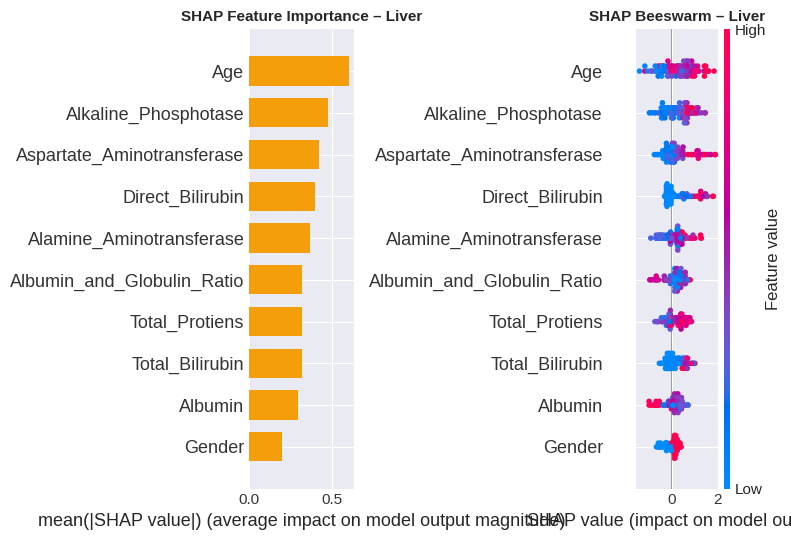

In [10]:
print("⏳ SHAP TreeExplainer...")
np.random.seed(42)
shap_idx = np.random.choice(len(X_test_d), min(2000, len(X_test_d)), replace=False)
X_shap = X_test_d[shap_idx]

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_shap)
print(f"✅ SHAP: {shap_values.shape}  Base={explainer.expected_value:.4f}")
joblib.dump(explainer, f'{DIR_MODELS}/liver_shap_explainer.pkl')
print("💾 Lưu: liver_shap_explainer.pkl")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
plt.sca(axes[0])
shap.summary_plot(shap_values, X_shap, feature_names=FEATURE_NAMES,
                  plot_type='bar', show=False, color='#f59e0b')
axes[0].set_title('SHAP Feature Importance – Liver',fontsize=11,weight='bold')
plt.sca(axes[1])
shap.summary_plot(shap_values, X_shap, feature_names=FEATURE_NAMES, show=False)
axes[1].set_title('SHAP Beeswarm – Liver',fontsize=11,weight='bold')
plt.tight_layout()
plt.savefig(f'{DIR_RESULTS}/L05_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## SHAP Waterfall

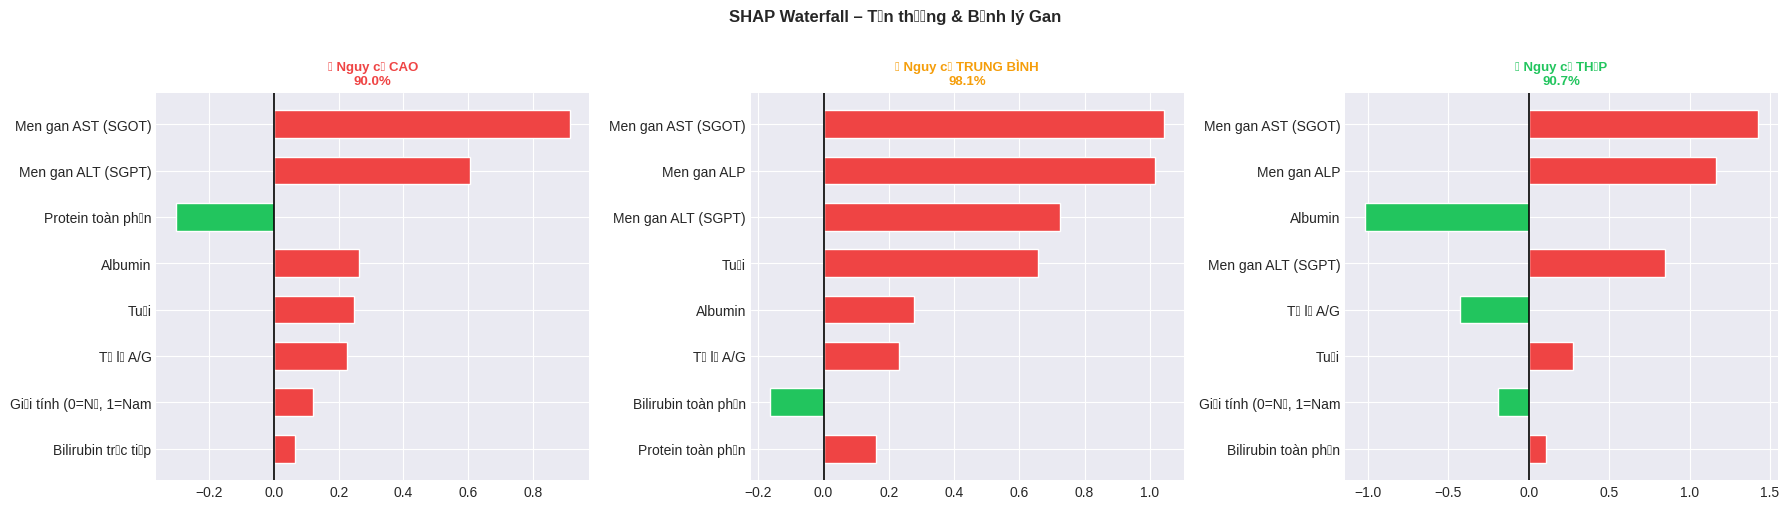

In [11]:
FEATURE_LABELS_L = {
    'Age': 'Tuổi', 'Gender': 'Giới tính (0=Nữ, 1=Nam)',
    'Total_Bilirubin': 'Bilirubin toàn phần', 'Direct_Bilirubin': 'Bilirubin trực tiếp',
    'Alkaline_Phosphotase': 'Men gan ALP', 'Alamine_Aminotransferase': 'Men gan ALT (SGPT)',
    'Aspartate_Aminotransferase': 'Men gan AST (SGOT)', 'Total_Protiens': 'Protein toàn phần',
    'Albumin': 'Albumin', 'Albumin_and_Globulin_Ratio': 'Tỷ lệ A/G'
}

def get_shap_explanation_liver(input_dict):
    model     = joblib.load(f'{DIR_MODELS}/liver_xgboost.pkl')
    scaler    = joblib.load(f'{DIR_MODELS}/liver_scaler.pkl')
    features  = joblib.load(f'{DIR_MODELS}/liver_features.pkl')
    explainer = joblib.load(f'{DIR_MODELS}/liver_shap_explainer.pkl')
    opt_t     = joblib.load(f'{DIR_MODELS}/liver_thresholds.pkl').get('f2_medical', 0.5)

    raw = [float(input_dict.get(f, 0)) for f in features]
    X_sc = scaler.transform(np.array(raw).reshape(1,-1))
    sv   = explainer.shap_values(X_sc)[0]
    prob = float(model.predict_proba(X_sc)[0][1])
    risk = 'High' if prob >= opt_t*1.5 else ('Medium' if prob >= opt_t else 'Low')

    feat_list = [{'name':f,'value':round(raw[i],2), 'shap_value':round(float(sv[i]),4), 'label_vn':FEATURE_LABELS_L.get(f,f)} for i,f in enumerate(features)]
    feat_list.sort(key=lambda x: abs(x['shap_value']), reverse=True)
    return {'prediction_prob':prob, 'risk_level':risk, 'features':feat_list}

CASES_LIVER = {
    '🔴 Nguy cơ CAO': {'Age':65, 'Gender':1, 'Total_Bilirubin':4.5, 'Direct_Bilirubin':2.2, 'Alkaline_Phosphotase':400, 'Alamine_Aminotransferase':150, 'Aspartate_Aminotransferase':200, 'Total_Protiens':5.0, 'Albumin':2.5, 'Albumin_and_Globulin_Ratio':0.8},
    '🟡 Nguy cơ TRUNG BÌNH': {'Age':45, 'Gender':1, 'Total_Bilirubin':1.5, 'Direct_Bilirubin':0.8, 'Alkaline_Phosphotase':250, 'Alamine_Aminotransferase':60, 'Aspartate_Aminotransferase':80, 'Total_Protiens':6.5, 'Albumin':3.5, 'Albumin_and_Globulin_Ratio':1.0},
    '🟢 Nguy cơ THẤP': {'Age':30, 'Gender':0, 'Total_Bilirubin':0.8, 'Direct_Bilirubin':0.2, 'Alkaline_Phosphotase':120, 'Alamine_Aminotransferase':25, 'Aspartate_Aminotransferase':30, 'Total_Protiens':7.5, 'Albumin':4.2, 'Albumin_and_Globulin_Ratio':1.2}
}

fig, axes = plt.subplots(1,3,figsize=(18,5))
colors_r = {'🔴 Nguy cơ CAO':'#ef4444','🟡 Nguy cơ TRUNG BÌNH':'#f59e0b','🟢 Nguy cơ THẤP':'#22c55e'}
for ax,(cname, cdata) in zip(axes, CASES_LIVER.items()):
    r = get_shap_explanation_liver(cdata)
    feats = r['features'][:8]
    names = [f['label_vn'][:22] for f in feats]
    svs   = [f['shap_value'] for f in feats]
    bc    = ['#ef4444' if v>0 else '#22c55e' for v in svs]
    ax.barh(names[::-1], svs[::-1], color=bc[::-1], edgecolor='white', height=0.6)
    ax.axvline(x=0, color='black', lw=1.2)
    ax.set_title(f"{cname}\n{r['prediction_prob']*100:.1f}%", fontsize=9.5, weight='bold', color=colors_r[cname])
plt.suptitle('SHAP Waterfall – Tổn thương & Bệnh lý Gan',fontsize=12,weight='bold',y=1.01)
plt.tight_layout()
plt.savefig(f'{DIR_RESULTS}/L06_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

---
## ✅ TỔNG KẾT

In [12]:
print("="*70); print("📦 ARTIFACTS ĐÃ TẠO – Liver"); print("="*70)
artifacts = {
    f'{DIR_MODELS}/liver_xgboost.pkl'       : 'XGBoost (583 mẫu)',
    f'{DIR_MODELS}/liver_shap_explainer.pkl': 'SHAP Explainer',
    f'{DIR_MODELS}/liver_scaler.pkl'        : 'StandardScaler',
    f'{DIR_MODELS}/liver_features.pkl'      : f'{len(FEATURE_NAMES)} features',
    f'{DIR_MODELS}/liver_test_raw.pkl'      : 'Test set raw',
}
import os
for path, desc in artifacts.items():
    ex=os.path.exists(path); sz=os.path.getsize(path)//1024 if ex else 0
    print(f"  {'✅' if ex else '❌'} {desc:45s} [{sz:4d}KB]")

print("\n📊 KẾT QUẢ MÔ HÌNH – Liver Disease (583)")
print("="*70)
print(f"  Accuracy  : {acc_xgb:.4f}  {'✅' if acc_xgb>=0.80 else '❌'}")
print(f"  Precision : {prec_xgb:.4f}  {'✅' if prec_xgb>=0.75 else '❌'}")
print(f"  Recall    : {rec_xgb:.4f}  {'✅' if rec_xgb>=0.75 else '❌'}")
print(f"  F1-Score  : {f1_xgb:.4f}  {'✅' if f1_xgb>=0.76 else '❌'}")
print(f"  AUC-ROC   : {auc_xgb:.4f}  {'✅' if auc_xgb>=0.82 else '❌'}")
print("="*70)

📦 ARTIFACTS ĐÃ TẠO – Liver
  ✅ XGBoost (583 mẫu)                             [ 445KB]
  ✅ SHAP Explainer                                [1565KB]
  ✅ StandardScaler                                [   1KB]
  ✅ 10 features                                   [   0KB]
  ✅ Test set raw                                  [  10KB]

📊 KẾT QUẢ MÔ HÌNH – Liver Disease (583)
  Accuracy  : 0.7521  ❌
  Precision : 0.8000  ✅
  Recall    : 0.8675  ✅
  F1-Score  : 0.8324  ✅
  AUC-ROC   : 0.7668  ❌
